In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pynwb import NWBHDF5IO
from pathlib import Path
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

def get_nwb_files(subject_id: str, session_id: str, 
                  base_path: str = '/oak/stanford/groups/ckeller1/data/iEEG_EHR/iEEG_NWB') -> List[Path]:
    """Get all preprocessed NWB files for a given subject and session."""
    preprocessed_dir = Path(base_path) / f'sub-{subject_id}' / f'ses-{session_id}' / 'preprocessed'
    nwb_files = sorted(preprocessed_dir.glob('*_bipolar_psd.nwb'))
    print(f"Found {len(nwb_files)} NWB files in {preprocessed_dir}")
    return nwb_files

def load_pain_scores(subject_id: str, session_id: str, 
                     base_path: str = '/oak/stanford/groups/ckeller1/data/iEEG_EHR/iEEG_NWB') -> pd.DataFrame:
    """Load pain scores from EHR folder."""
    ehr_dir = Path(base_path) / f'sub-{subject_id}' / f'ses-{session_id}' / 'ehr'
    pain_file = ehr_dir / f'sub-{subject_id}_ses-{session_id}_pain-scores.csv'
    
    if not pain_file.exists():
        raise FileNotFoundError(f"Pain scores file not found: {pain_file}")
    
    # Load pain scores
    pain_df = pd.read_csv(pain_file)
    
    # Convert date column to datetime
    pain_df['date'] = pd.to_datetime(pain_df['date'])
    
    # Filter for this specific subject and session
    pain_df = pain_df[(pain_df['sub_id'] == f'sub-{subject_id}') & 
                      (pain_df['ses_id'] == f'ses-{session_id}')]
    
    print(f"Loaded {len(pain_df)} pain scores for sub-{subject_id}, ses-{session_id}")
    
    return pain_df

def load_electrode_labels(nwb_file_path: Path) -> Dict[int, str]:
    """Load electrode labels from NWB file."""
    electrode_labels = {}
    try:
        with NWBHDF5IO(str(nwb_file_path), 'r') as io:
            nwb = io.read()
            electrodes_df = nwb.electrodes.to_dataframe()
            
            if 'Desikan_Killiany_cathode' in electrodes_df.columns:
                for idx, row in electrodes_df.iterrows():
                    label = row['Desikan_Killiany_cathode']
                    # Handle NaN or empty labels
                    if pd.isna(label) or label == '' or label == 'nan':
                        electrode_labels[idx] = f'Ch{idx}'
                    else:
                        electrode_labels[idx] = str(label)
                print(f"Loaded electrode labels for {len(electrode_labels)} channels")
            else:
                print("Warning: 'Desikan_Killiany_cathode' column not found")
                print(f"Available columns: {list(electrodes_df.columns)}")
    except Exception as e:
        print(f"Warning: Could not load electrode labels: {e}")
    
    return electrode_labels

def filter_valid_channels(electrode_labels: Dict[int, str]) -> Dict[int, str]:
    """
    Filter out channels with 'unknown' or 'white-matter' in their labels.
    
    Returns:
        Dictionary of valid electrode labels (filtered)
    """
    valid_labels = {}
    filtered_count = 0
    
    for ch_idx, label in electrode_labels.items():
        label_lower = label.lower()
        # Check if label contains 'unknown' or 'white-matter' (or 'white matter')
        if 'unknown' in label_lower or 'white-matter' in label_lower or 'white matter' in label_lower:
            filtered_count += 1
            continue
        valid_labels[ch_idx] = label
    
    print(f"Filtered out {filtered_count} channels (unknown/white-matter)")
    print(f"Remaining valid channels: {len(valid_labels)}")
    
    return valid_labels

def extract_bandpower_windows(nwb_file: Path, pain_df: pd.DataFrame, 
                              window_minutes: int = 5, 
                              band_names: List[str] = ['delta', 'theta', 'alpha', 'beta', 'gamma', 'high_gamma']) -> Dict:
    """
    Extract bandpower for 5-minute windows before each pain score, along with the pain score value.
    
    Returns:
        dict: {channel_idx: {band_name: [(bandpower, pain_score), ...]}}
    """
    channel_band_data = {}
    
    try:
        with NWBHDF5IO(str(nwb_file), 'r') as io:
            nwb = io.read()
            
            # Get session start time
            session_start = nwb.session_start_time
            
            # Load band power data
            band_power_series = nwb.processing['ecephys']["band_power"]
            band_power_data = band_power_series.data[:]  # Shape: (timepoints, channels, bands)
            
            # Get timestamps
            if band_power_series.timestamps is not None:
                band_power_timestamps = band_power_series.timestamps[:]
            else:
                # Reconstruct timestamps from starting_time and rate
                starting_time = band_power_series.starting_time
                rate = band_power_series.rate
                n_timepoints = band_power_data.shape[0]
                band_power_timestamps = starting_time + np.arange(n_timepoints) / rate
            
            # Convert timestamps to datetime (relative to session start)
            band_power_datetimes = pd.to_datetime(session_start) + pd.to_timedelta(band_power_timestamps, unit='s')
            
            # Remove timezone info to match pain timestamps
            band_power_datetimes = band_power_datetimes.tz_localize(None)
            
            # Iterate through each pain event
            events_found = 0
            for idx, row in pain_df.iterrows():
                pain_time = row['date']
                pain_score = row['max_pain']
                
                # Skip if pain score is NaN
                if pd.isna(pain_score):
                    continue
                
                # Calculate window start time (5 minutes before pain score)
                window_start = pain_time - pd.Timedelta(minutes=window_minutes)
                
                # Find indices within the 5-minute window    wspace=0.3, hspace=0set_yscale.4, right=0.95)
                mask = (band_power_datetimes >= window_start) & (band_power_datetimes < pain_time)
                
                if not np.any(mask):
                    continue
                
                events_found += 1
                
                # Get data for this window
                window_data = band_power_data[mask, :, :]  # Shape: (time_in_window, channels, bands)
                
                # Average across time for each channel and band
                mean_bandpower = np.mean(window_data, axis=0)  # Shape: (channels, bands)
                
                # Store data organized by channel and band, including pain score
                n_channels = mean_bandpower.shape[0]
                for ch_idx in range(n_channels):
                    if ch_idx not in channel_band_data:
                        channel_band_data[ch_idx] = {band: [] for band in band_names}
                    
                    for band_idx, band_name in enumerate(band_names):
                        channel_band_data[ch_idx][band_name].append(
                            (mean_bandpower[ch_idx, band_idx], pain_score)
                        )
            
    except Exception as e:
        print(f"  Error processing {nwb_file.name}: {e}")
        return {}
    
    return channel_band_data

def load_session_data(subject_id: str, session_id: str,
                     window_minutes: int = 5,
                     band_names: List[str] = ['delta', 'theta', 'alpha', 'beta', 'gamma', 'high_gamma'],
                     filter_channels: bool = True) -> Tuple[Dict, Dict[int, str], pd.DataFrame]:
    """
    Load all data for a session - separates data loading from plotting.
    
    Args:
        filter_channels: If True, filters out channels with 'unknown' or 'white-matter' labels
    
    Returns:
        Tuple of (all_channel_band_data, electrode_labels, summary_dataframe)
    """
    print(f"\n{'='*60}")
    print(f"Loading Data for Subject {subject_id}, Session {session_id}")
    print(f"{'='*60}\n")
    
    # Load pain scores
    pain_df = load_pain_scores(subject_id, session_id)
    
    if len(pain_df) == 0:
        print("No pain scores found!")
        return None, None, None
    
    # Get all NWB files
    nwb_files = get_nwb_files(subject_id, session_id)
    
    if len(nwb_files) == 0:
        print("No NWB files found!")
        return None, None, None
    
    # Load electrode labels from first NWB file
    print("\nLoading electrode labels...")
    electrode_labels = load_electrode_labels(nwb_files[0])
    
    # Filter channels if requested
    if filter_channels:
        print("\nFiltering channels...")
        electrode_labels = filter_valid_channels(electrode_labels)
        valid_channel_indices = set(electrode_labels.keys())
    else:
        valid_channel_indices = None
    
    # Collect bandpower data across all runs
    all_channel_band_data = {}
    
    print(f"\nExtracting {window_minutes}-minute windows before pain scores...")
    print(f"Processing {len(nwb_files)} files (progress updates every 10 files)...")
    
    for file_idx, nwb_file in enumerate(nwb_files):
        if (file_idx + 1) % 10 == 0 or (file_idx + 1) == len(nwb_files):
            print(f"  Processed {file_idx + 1}/{len(nwb_files)} files...")
        
        file_data = extract_bandpower_windows(nwb_file, pain_df, window_minutes, band_names)
        
        # Merge with overall data (only for valid channels if filtering)
        for ch_idx, band_dict in file_data.items():
            # Skip filtered channels
            if valid_channel_indices is not None and ch_idx not in valid_channel_indices:
                continue
                
            if ch_idx not in all_channel_band_data:
                all_channel_band_data[ch_idx] = {band: [] for band in band_names}
            
            for band_name, values in band_dict.items():
                all_channel_band_data[ch_idx][band_name].extend(values)
    
    # Create summary DataFrame
    summary_data = []
    for ch_idx, band_dict in all_channel_band_data.items():
        for band_name, values in band_dict.items():
            for bandpower, pain_score in values:
                summary_data.append({
                    'Channel': ch_idx,
                    'Channel_Label': electrode_labels.get(ch_idx, f'Ch{ch_idx}'),
                    'Band': band_name,
                    'Bandpower': bandpower,
                    'PainScore': pain_score
                })
    
    df_summary = pd.DataFrame(summary_data)
    
    print(f"\n{'='*60}")
    print(f"Data loading complete!")
    print(f"Total data points: {len(df_summary)}")
    print(f"Channels: {len(all_channel_band_data)}")
    print(f"{'='*60}\n")
    
    return all_channel_band_data, electrode_labels, df_summary

def plot_channel_bandpower_vs_pain(all_channel_band_data: Dict,
                                   electrode_labels: Dict[int, str],
                                   subject_id: str, 
                                   session_id: str,
                                   output_dir: str = './plots',
                                   window_minutes: int = 5,
                                   band_names: List[str] = ['delta', 'theta', 'alpha', 'beta', 'gamma', 'high_gamma'],
                                   n_channels_to_plot: int = None,
                                   subplots_per_row: int = 5,
                                   jitter_amount: float = 0.1):
    """
    Create scatter plots showing bandpower vs frequency band colored by pain score.
    One subplot per channel.
    """
    
    # Determine which channels to plot (only those in electrode_labels)
    available_channels = [ch for ch in all_channel_band_data.keys() if ch in electrode_labels]
    channels_to_plot = sorted(available_channels)
    
    if n_channels_to_plot is not None:
        channels_to_plot = channels_to_plot[:n_channels_to_plot]
    
    n_channels = len(channels_to_plot)
    if n_channels == 0:
        print("No channels to plot!")
        return
    
    # Calculate grid dimensions
    n_cols = subplots_per_row
    n_rows = int(np.ceil(n_channels / n_cols))
    
    # Create figure with extra space on the right for colorbar
    fig_width = n_cols * 4 + 1.5  # Add extra space for colorbar
    fig_height = n_rows * 3
    fig = plt.figure(figsize=(fig_width, fig_height))
    
    # Create grid spec with space for colorbar
    gs = fig.add_gridspec(n_rows, n_cols + 1, width_ratios=[1]*n_cols + [0.05], 
                          wspace=0.3, hspace=0.4, right=0.95)
    
    # Prepare data for plotting
    band_positions = np.arange(len(band_names))
    
    # Find global min/max pain scores for consistent colormap
    all_pain_scores = []
    for ch_idx in channels_to_plot:
        for band_name in band_names:
            if band_name in all_channel_band_data[ch_idx]:
                for _, pain_score in all_channel_band_data[ch_idx][band_name]:
                    all_pain_scores.append(pain_score)
    
    if len(all_pain_scores) == 0:
        print("No data to plot!")
        return
    
    vmin = min(all_pain_scores)
    vmax = max(all_pain_scores)
    
    print(f"\nCreating plots for {n_channels} channels...")
    print(f"Pain score range: {vmin} - {vmax}")
    
    # Plot each channel
    scatter = None
    for plot_idx, ch_idx in enumerate(channels_to_plot):
        row = plot_idx // n_cols
        col = plot_idx % n_cols
        ax = fig.add_subplot(gs[row, col])
        
        # Collect data for this channel
        for band_idx, band_name in enumerate(band_names):
            if band_name not in all_channel_band_data[ch_idx]:
                continue
            
            data_points = all_channel_band_data[ch_idx][band_name]
            
            if len(data_points) == 0:
                continue
            
            # Extract bandpower and pain scores
            bandpowers = [bp for bp, _ in data_points]
            pain_scores = [ps for _, ps in data_points]
            
            # Add jitter to x-positions
            x_positions = band_idx + np.random.uniform(-jitter_amount, jitter_amount, len(bandpowers))
            
            # Create scatter plot colored by pain score
            scatter = ax.scatter(x_positions, bandpowers, c=pain_scores, 
                               cmap='RdYlBu_r', vmin=vmin, vmax=vmax,
                               alpha=0.6, s=20)
        
        # Formatting
        ax.set_xticks(band_positions)
        ax.set_xticklabels([b.capitalize() for b in band_names], rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('Avg Bandpower (μV²/Hz)', fontsize=8)
        
        # Use electrode label
        title = electrode_labels[ch_idx]
        ax.set_title(title, fontsize=9, fontweight='bold')
        
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_xlim(-0.5, len(band_names) - 0.5)
    
    # Add colorbar in the last column
    if scatter is not None:
        cbar_ax = fig.add_subplot(gs[:, -1])
        cbar = fig.colorbar(scatter, cax=cbar_ax)
        cbar.set_label('Pain Score', fontsize=10)
        cbar.ax.tick_params(labelsize=8)
    
    # Overall title
    fig.suptitle(f'Bandpower vs Frequency Band (colored by Pain Score)\n' +
                 f'Subject {subject_id}, Session {session_id} | {window_minutes}-min windows before pain scores',
                 fontsize=14, fontweight='bold', y=0.995)
    
    # Save plot
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    output_file = Path(output_dir) / f'sub-{subject_id}_ses-{session_id}_bandpower_vs_pain.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"\nSaved: {output_file}")
    plt.show()
    plt.close()

Step 1: Loading data...

Loading Data for Subject 001, Session 01



FileNotFoundError: Seizure file not found: /oak/stanford/groups/ckeller1/data/iEEG_EHR/iEEG_NWB/sub-001/ses-01/ehr/sub-001_ses-01_seizures.csv

In [2]:
# Step 1: Load data once
subject_id = '231'
session_id = '01'

all_channel_band_data, electrode_labels, df_summary = load_session_data(
    subject_id=subject_id,
    session_id=session_id,
    window_minutes=5,
    band_names=['delta', 'theta', 'alpha', 'beta', 'gamma', 'high_gamma']
)


Loading Data for Subject 231, Session 01

Loaded 119 pain scores for sub-231, ses-01
Found 153 NWB files in /oak/stanford/groups/ckeller1/data/iEEG_EHR/iEEG_NWB/sub-231/ses-01/preprocessed

Loading electrode labels...
Loaded electrode labels for 127 channels

Filtering channels...
Filtered out 29 channels (unknown/white-matter)
Remaining valid channels: 98

Extracting 5-minute windows before pain scores...
Processing 153 files (progress updates every 10 files)...
  Processed 10/153 files...
  Processed 20/153 files...
  Processed 30/153 files...
  Processed 40/153 files...
  Processed 50/153 files...
  Processed 60/153 files...
  Processed 70/153 files...
  Processed 80/153 files...
  Processed 90/153 files...
  Processed 100/153 files...
  Processed 110/153 files...
  Processed 120/153 files...
  Processed 130/153 files...
  Processed 140/153 files...
  Processed 150/153 files...
  Processed 153/153 files...

Data loading complete!
Total data points: 66444
Channels: 98



In [5]:
def plot_channel_bandpower_with_outliers(all_channel_band_data: Dict,
                                         electrode_labels: Dict[int, str],
                                         subject_id: str, 
                                         session_id: str,
                                         output_dir: str = './plots',
                                         window_minutes: int = 5,
                                         band_names: List[str] = ['delta', 'theta', 'alpha', 'beta', 'gamma', 'high_gamma'],
                                         n_channels_to_plot: int = None,
                                         subplots_per_row: int = 5,
                                         outlier_std_threshold: float = 5.0,
                                         jitter_amount: float = 0.1,
                                         log_scale: bool = False,
                                         exclude_outliers: bool = False,
                                         detect_outliers_in_log_space: bool = False):
    """
    Create violin plots with individual data points overlaid.
    Outliers (>5 std from mean) are highlighted in bright pink or excluded.
    
    Args:
        exclude_outliers: If True, removes outliers from the plot entirely. 
                         If False, highlights them in pink.
        detect_outliers_in_log_space: If True, calculates outliers in log space.
                                      Useful when data spans many orders of magnitude.
    
    Note: When a trial is identified as an outlier in ANY band, it is excluded 
          from ALL bands for that channel.
    """
    
    # Determine which channels to plot
    available_channels = [ch for ch in all_channel_band_data.keys() if ch in electrode_labels]
    channels_to_plot = sorted(available_channels)
    
    if n_channels_to_plot is not None:
        channels_to_plot = channels_to_plot[:n_channels_to_plot]
    
    n_channels = len(channels_to_plot)
    if n_channels == 0:
        print("No channels to plot!")
        return
    
    # Calculate grid dimensions
    n_cols = subplots_per_row
    n_rows = int(np.ceil(n_channels / n_cols))
    
    # Create figure
    fig_width = n_cols * 5
    fig_height = n_rows * 3
    fig = plt.figure(figsize=(fig_width, fig_height))
    
    # Create grid spec
    gs = fig.add_gridspec(n_rows, n_cols, wspace=0.3, hspace=0.4, right=0.95)
    
    action_text = "excluding" if exclude_outliers else "highlighting"
    space_text = "log space" if detect_outliers_in_log_space else "linear space"
    print(f"\nCreating plots with outlier detection ({action_text}) for {n_channels} channels...")
    print(f"Outlier threshold: {outlier_std_threshold} standard deviations above mean in {space_text}")
    print(f"Note: Trials identified as outliers in ANY band are excluded from ALL bands")
    
    # Count total outliers across all data
    total_outliers = 0
    total_trials = 0
    
    # Plot each channel
    for plot_idx, ch_idx in enumerate(channels_to_plot):
        row = plot_idx // n_cols
        col = plot_idx % n_cols
        ax = fig.add_subplot(gs[row, col])
        
        # First pass: collect all bandpower values for this channel to calculate threshold
        all_bandpowers = []
        for band_name in band_names:
            if band_name not in all_channel_band_data[ch_idx]:
                continue
            
            data_points = all_channel_band_data[ch_idx][band_name]
            
            for bp, ps in data_points:
                all_bandpowers.append(bp)
        
        if len(all_bandpowers) == 0:
            ax.axis('off')
            continue
        
        # Calculate outlier threshold for this channel (across all bands)
        if detect_outliers_in_log_space:
            # Work in log space
            log_bandpowers = np.log10(np.array(all_bandpowers) + 1e-10)  # Add small value to avoid log(0)
            mean_log_bp = np.mean(log_bandpowers)
            std_log_bp = np.std(log_bandpowers)
            log_threshold = mean_log_bp + outlier_std_threshold * std_log_bp
            # Convert back to linear space
            outlier_threshold = 10 ** log_threshold
        else:
            # Work in linear space
            mean_bp = np.mean(all_bandpowers)
            std_bp = np.std(all_bandpowers)
            outlier_threshold = mean_bp + outlier_std_threshold * std_bp
        
        # Second pass: identify which trials (indexed by position) are outliers in ANY band
        # Assuming all bands have the same trials in the same order
        n_trials = len(all_channel_band_data[ch_idx][band_names[0]])
        total_trials += n_trials
        
        outlier_trial_indices = set()
        
        for band_name in band_names:
            if band_name not in all_channel_band_data[ch_idx]:
                continue
            
            data_points = all_channel_band_data[ch_idx][band_name]
            
            for trial_idx, (bp, ps) in enumerate(data_points):
                if bp > outlier_threshold:
                    outlier_trial_indices.add(trial_idx)
        
        channel_outliers = len(outlier_trial_indices)
        total_outliers += channel_outliers
        
        # Third pass: prepare data for plotting, excluding outlier trials from ALL bands
        plot_data = []
        
        for band_name in band_names:
            if band_name not in all_channel_band_data[ch_idx]:
                continue
            
            data_points = all_channel_band_data[ch_idx][band_name]
            
            for trial_idx, (bp, ps) in enumerate(data_points):
                # Skip this trial if it's an outlier in ANY band
                if exclude_outliers and trial_idx in outlier_trial_indices:
                    continue
                    
                plot_data.append({
                    'Band': band_name.capitalize(),
                    'Bandpower': bp,
                    'trial_idx': trial_idx
                })
        
        if len(plot_data) == 0:
            ax.axis('off')
            continue
        
        df_plot = pd.DataFrame(plot_data)
        
        # Create violin plot (only includes non-outlier data if exclude_outliers=True)
        sns.violinplot(data=df_plot, x='Band', y='Bandpower', 
                      ax=ax, color='lightblue', inner=None, linewidth=1)
        
        # Overlay individual points
        band_positions = {band: i for i, band in enumerate([b.capitalize() for b in band_names])}
        
        for band_name in band_names:
            if band_name not in all_channel_band_data[ch_idx]:
                continue
            
            data_points = all_channel_band_data[ch_idx][band_name]
            band_position = band_positions[band_name.capitalize()]
            
            # Separate trials into normal and outlier
            normal_bandpowers = []
            outlier_bandpowers = []
            normal_x = []
            outlier_x = []
            
            for trial_idx, (bp, ps) in enumerate(data_points):
                x_pos = band_position + np.random.uniform(-jitter_amount, jitter_amount)
                
                if trial_idx in outlier_trial_indices:
                    outlier_bandpowers.append(bp)
                    outlier_x.append(x_pos)
                else:
                    normal_bandpowers.append(bp)
                    normal_x.append(x_pos)
            
            if exclude_outliers:
                # Only plot normal points (outliers are excluded)
                if len(normal_bandpowers) > 0:
                    ax.scatter(normal_x, normal_bandpowers, 
                              c='black', alpha=0.3, s=10, zorder=3)
            else:
                # Plot normal points in black
                if len(normal_bandpowers) > 0:
                    ax.scatter(normal_x, normal_bandpowers, 
                              c='black', alpha=0.3, s=10, zorder=3)
                
                # Plot outliers in bright pink/magenta
                if len(outlier_bandpowers) > 0:
                    ax.scatter(outlier_x, outlier_bandpowers, 
                              c='#FF1493', alpha=0.8, s=15, zorder=4, 
                              edgecolors='black', linewidths=0.5)
        
        # Set log scale if requested
        if log_scale:
            ax.set_yscale('log')
        
        # Formatting
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
        ax.set_xlabel('')
        ax.set_ylabel('Avg Bandpower (μV²/Hz)' + (' [log scale]' if log_scale else ''), fontsize=8)
        
        # Use electrode label with outlier count
        title = f"{electrode_labels[ch_idx]}"
        if channel_outliers > 0:
            if exclude_outliers:
                title += f" ({channel_outliers} trials excluded)"
            else:
                title += f" ({channel_outliers} outlier trials)"
        ax.set_title(title, fontsize=9, fontweight='bold')
        
        ax.grid(True, alpha=0.3, axis='y')
    
    # Print summary
    print(f"\nOutlier Summary:")
    print(f"  Total trials: {total_trials}")
    if exclude_outliers:
        print(f"  Total trials excluded (>{outlier_std_threshold} std in {space_text}): {total_outliers}")
        print(f"  Remaining trials: {total_trials - total_outliers}")
        print(f"  Percentage excluded: {100 * total_outliers / total_trials:.2f}%")
    else:
        print(f"  Total outlier trials (>{outlier_std_threshold} std in {space_text}): {total_outliers}")
        print(f"  Percentage: {100 * total_outliers / total_trials:.2f}%")
    
    # Overall title
    scale_text = ' [Log Scale]' if log_scale else ''
    if exclude_outliers:
        status_text = f'{total_outliers}/{total_trials} trials excluded ({space_text})'
    else:
        status_text = f'Pink points: >{outlier_std_threshold} std above mean in {space_text} ({total_outliers}/{total_trials} trials)'
    
    fig.suptitle(f'Bandpower Distribution with Outlier Detection{scale_text}\n' +
                 f'Subject {subject_id}, Session {session_id} | {window_minutes}-min windows\n' +
                 status_text,
                 fontsize=14, fontweight='bold', y=0.995)
    
    # Save plot
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    filename_suffix = '_log' if log_scale else ''
    exclude_suffix = '_excluded' if exclude_outliers else ''
    space_suffix = '_logspace' if detect_outliers_in_log_space else ''
    output_file = Path(output_dir) / f'sub-{subject_id}_ses-{session_id}_bandpower_outliers{exclude_suffix}{space_suffix}{filename_suffix}.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"\nSaved: {output_file}")
    plt.show()



Creating plots with outlier detection (highlighting) for 98 channels...
Outlier threshold: 5.0 standard deviations above mean in log space
Note: Trials identified as outliers in ANY band are excluded from ALL bands

Outlier Summary:
  Total trials: 11074
  Total outlier trials (>5.0 std in log space): 92
  Percentage: 0.83%

Saved: plot/sub-231_ses-01_bandpower_outliers_logspace_log.png


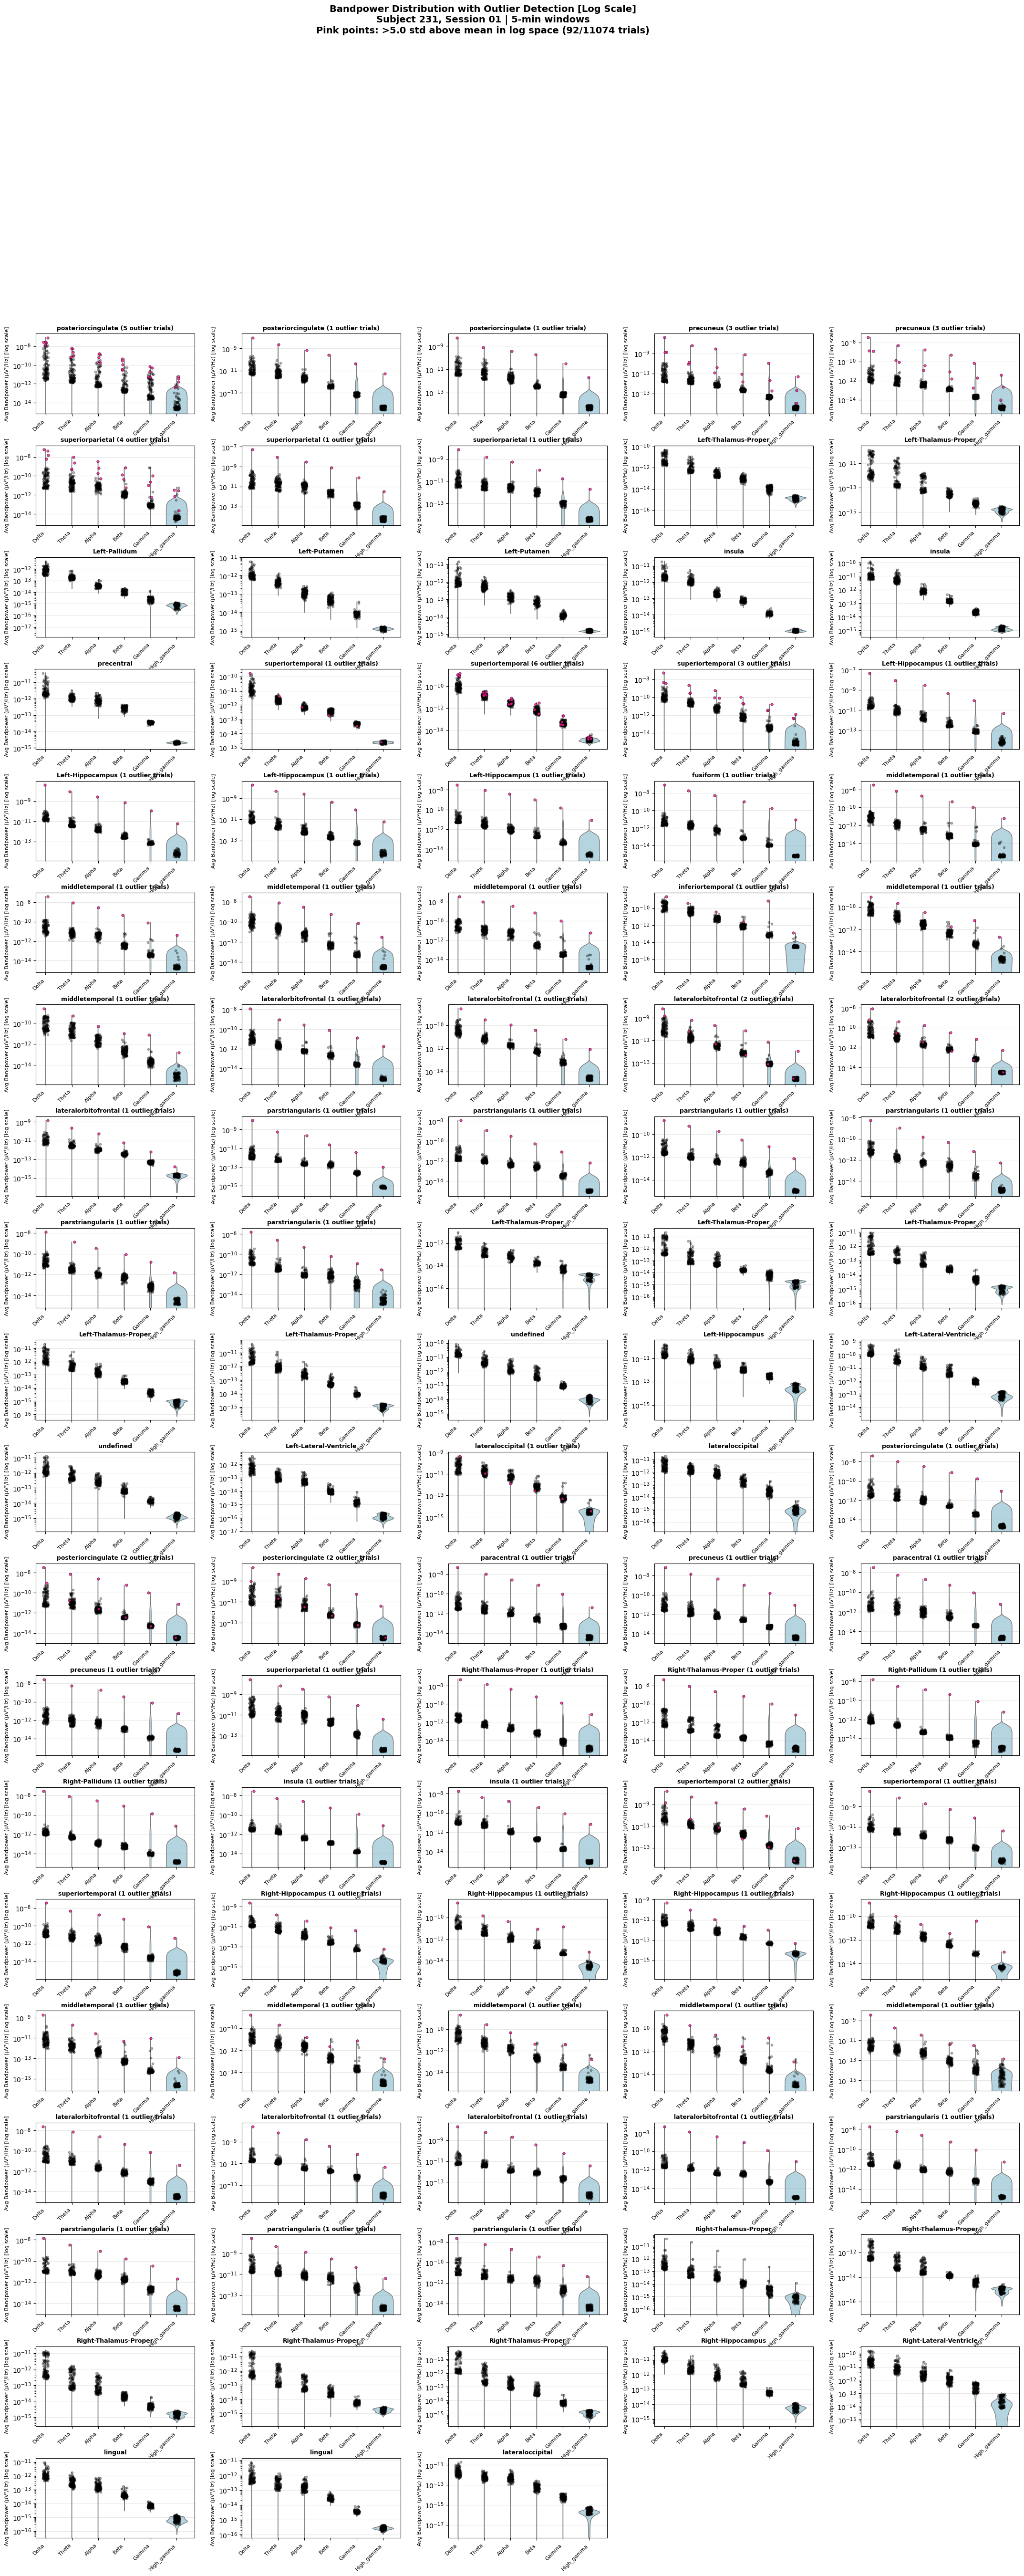


Creating plots with outlier detection (excluding) for 98 channels...
Outlier threshold: 5.0 standard deviations above mean in log space
Note: Trials identified as outliers in ANY band are excluded from ALL bands

Outlier Summary:
  Total trials: 11074
  Total trials excluded (>5.0 std in log space): 92
  Remaining trials: 10982
  Percentage excluded: 0.83%

Saved: plot/sub-231_ses-01_bandpower_outliers_excluded_logspace_log.png


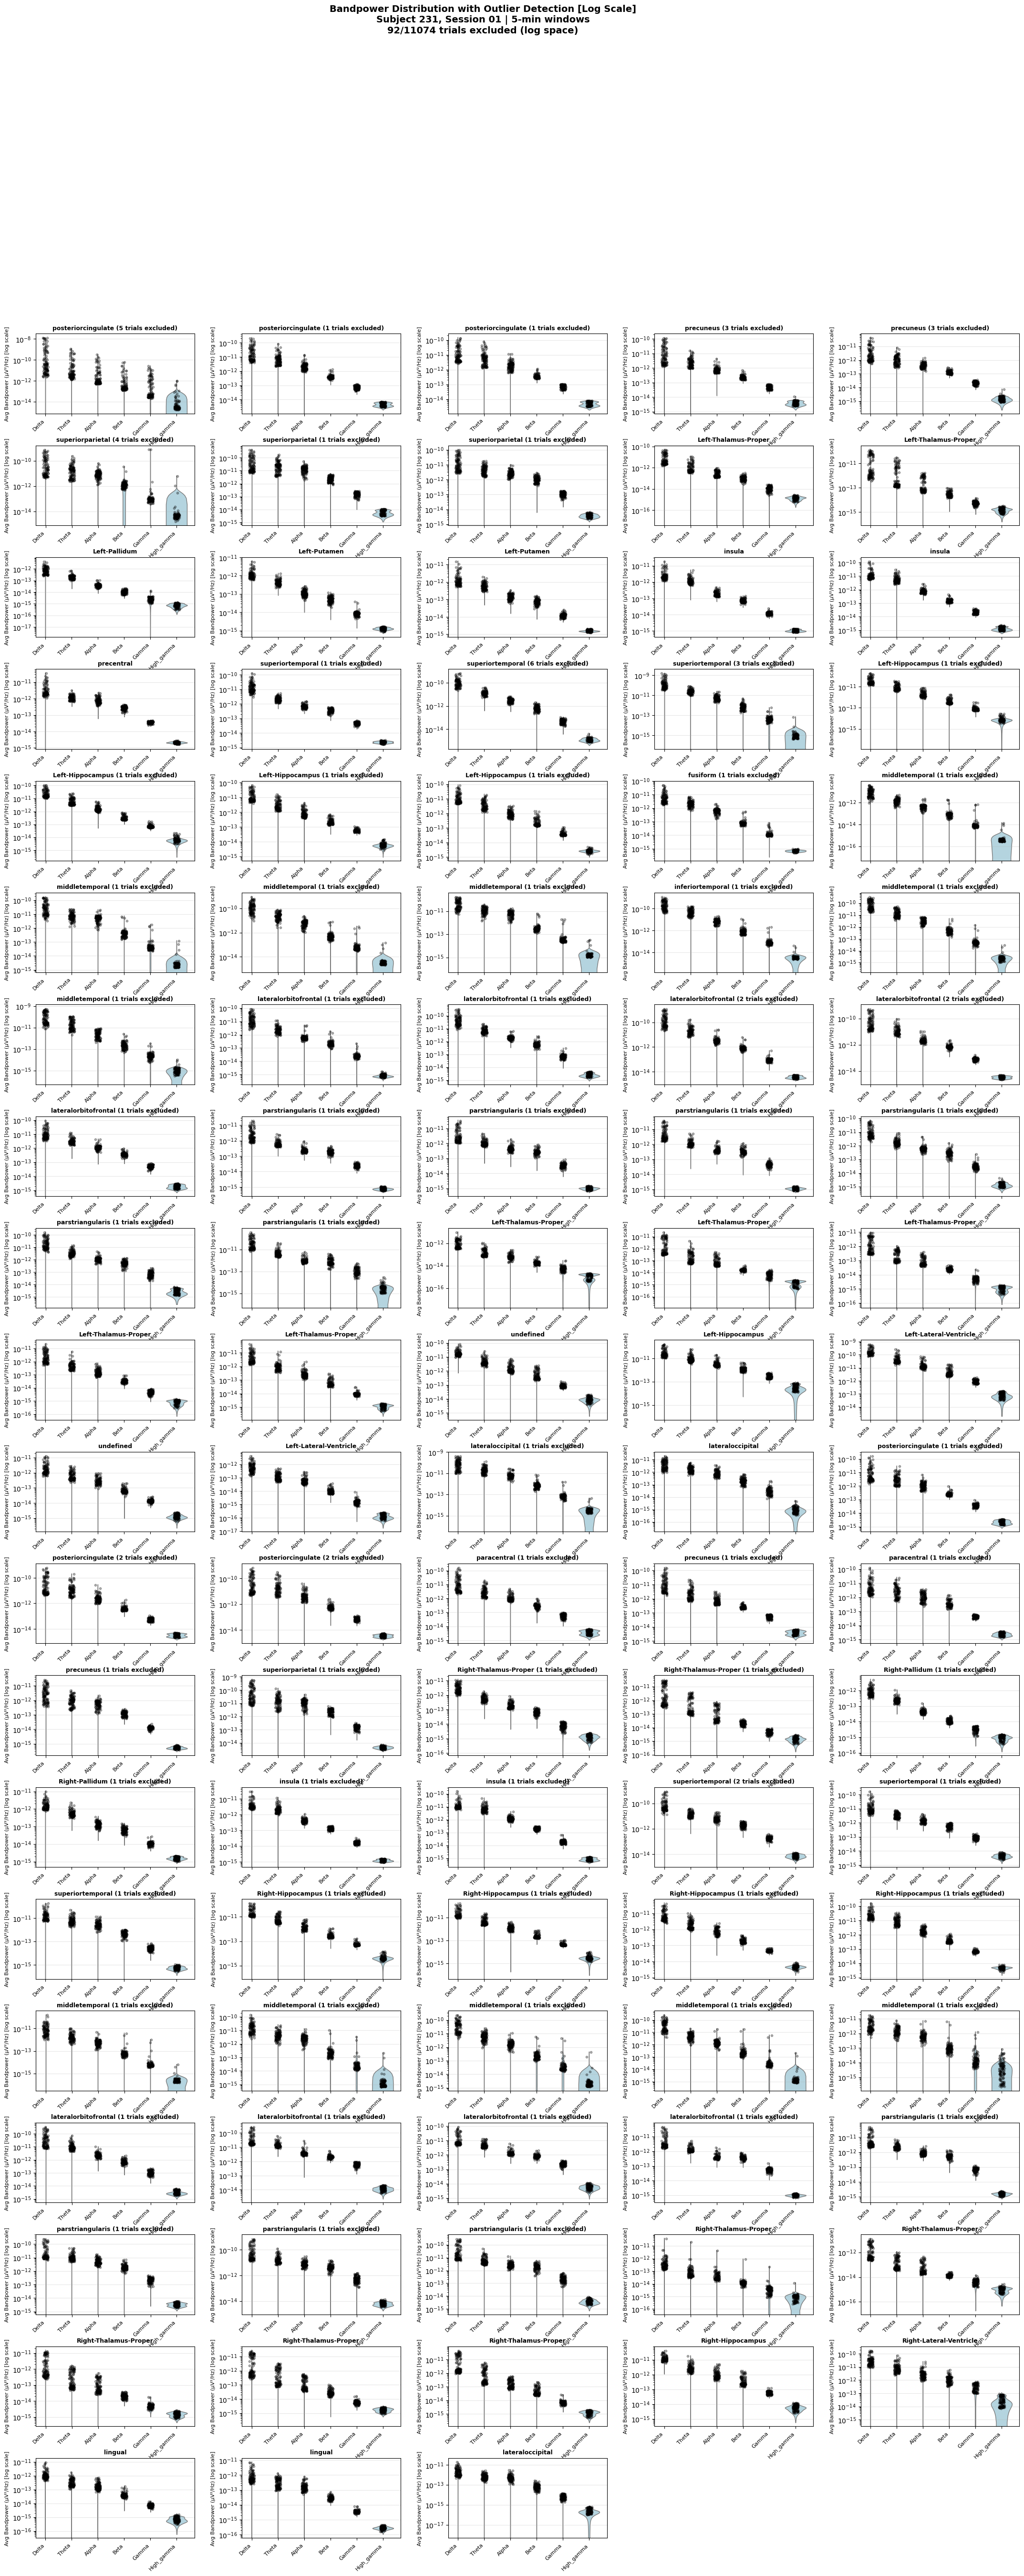

In [4]:
# Highlight outliers (don't exclude)
plot_channel_bandpower_with_outliers(
    all_channel_band_data=all_channel_band_data,
    electrode_labels=electrode_labels,
    subject_id=subject_id,
    session_id=session_id,
    output_dir='plot/',
    outlier_std_threshold=5.0,
    exclude_outliers=False,
    log_scale=True,
    detect_outliers_in_log_space=True# Just highlight in pink
)

# Exclude outliers completely
plot_channel_bandpower_with_outliers(
    all_channel_band_data=all_channel_band_data,
    electrode_labels=electrode_labels,
    subject_id=subject_id,
    session_id=session_id,
    output_dir='plot/',
    outlier_std_threshold=5.0,
    log_scale=True,
    detect_outliers_in_log_space=True,# Just highlight in pink
    exclude_outliers=True  # Remove from plot entirely
)


Creating plots with outlier detection (highlighting) for 98 channels...
Outlier threshold: 4.0 standard deviations above mean in log space
Note: Trials identified as outliers in ANY band are excluded from ALL bands

Outlier Summary:
  Total trials: 11074
  Total outlier trials (>4.0 std in log space): 148
  Percentage: 1.34%

Saved: plot/sub-231_ses-01_bandpower_outliers_logspace_log.png


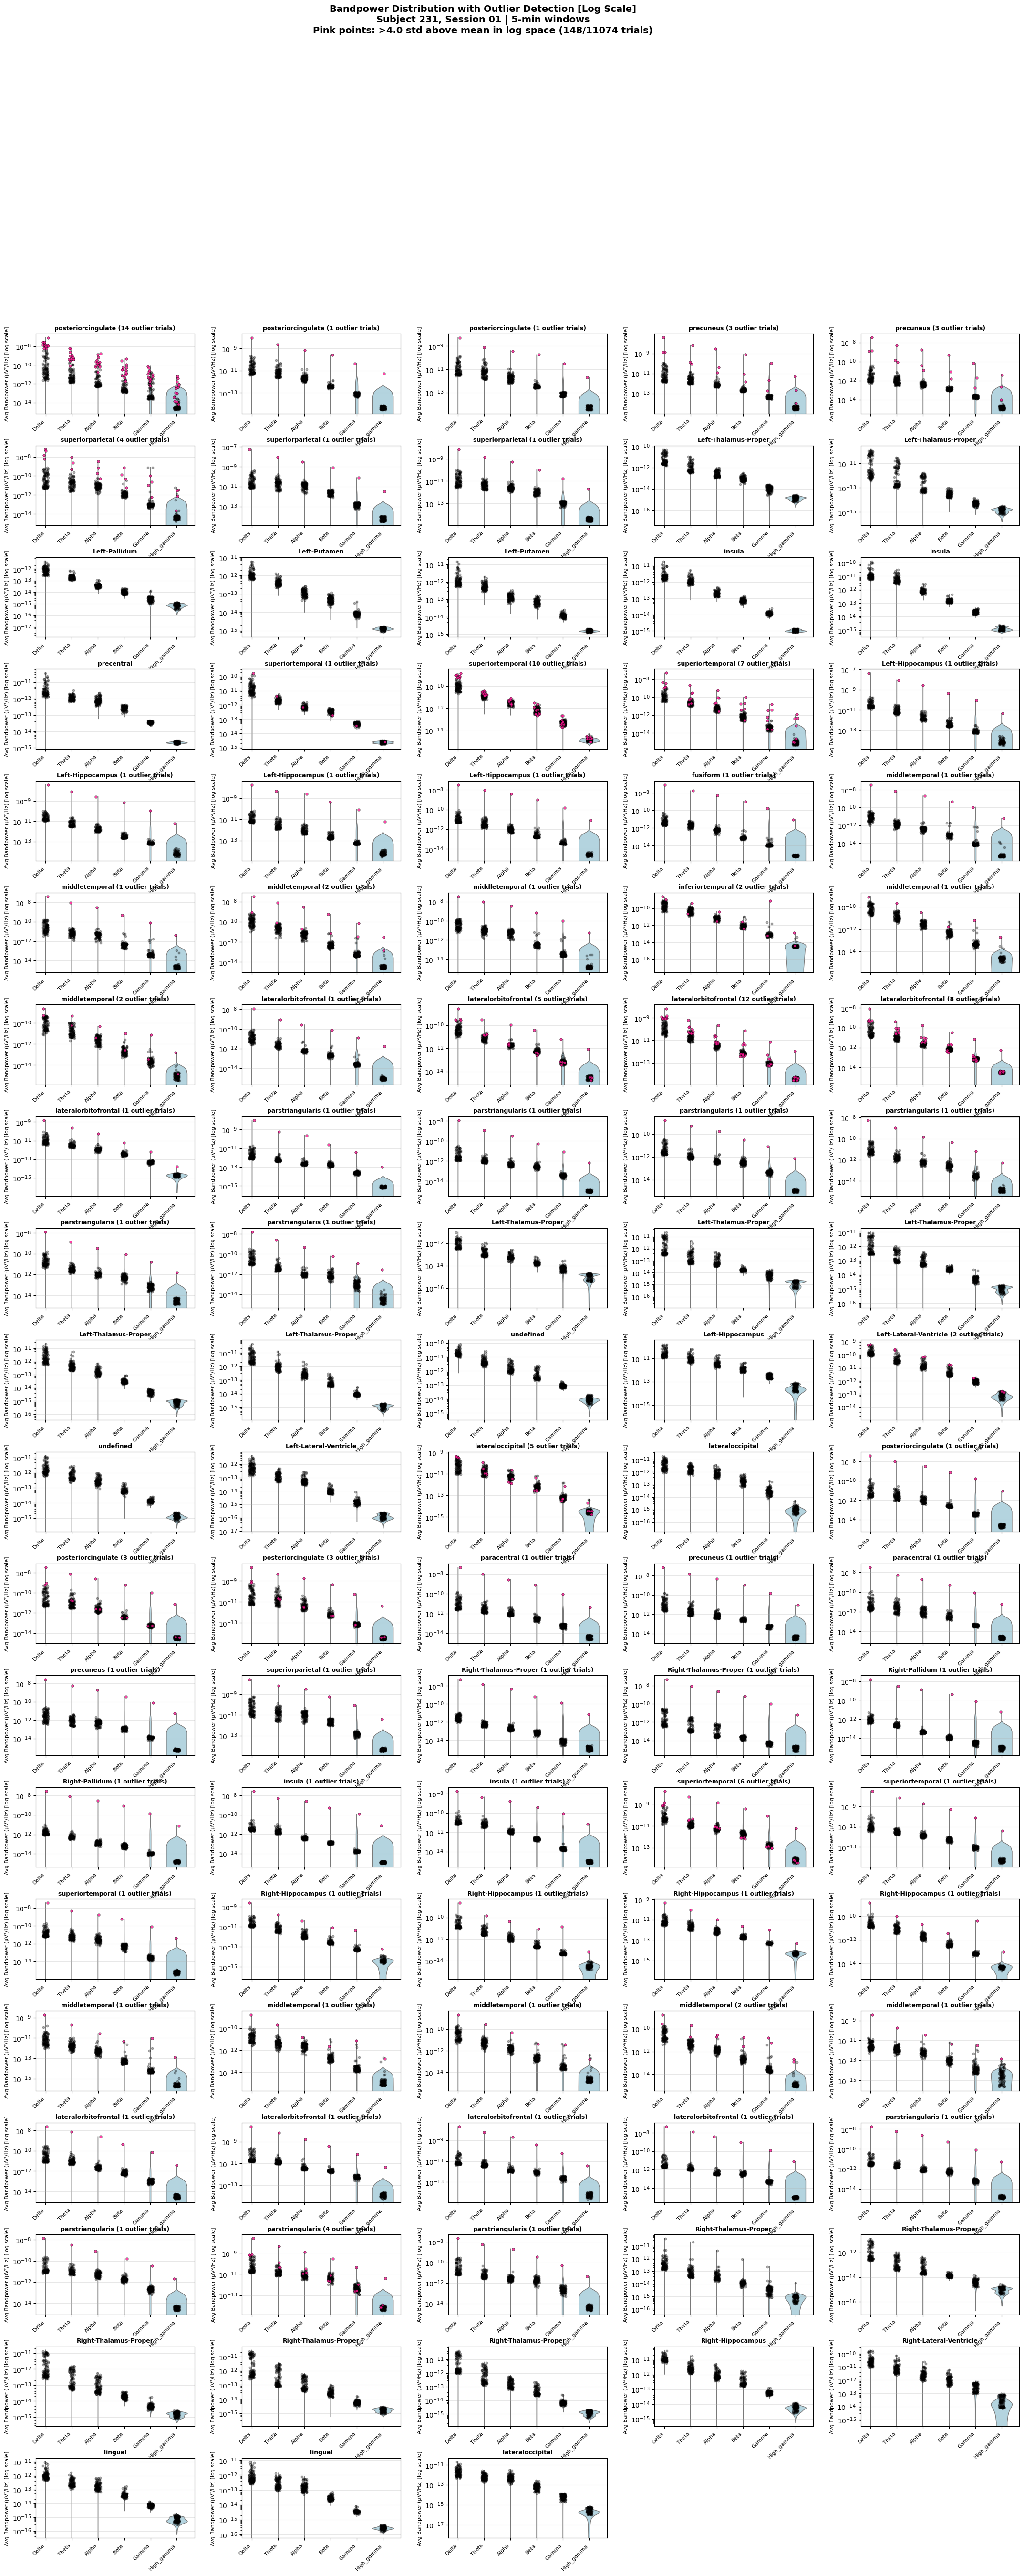


Creating plots with outlier detection (excluding) for 98 channels...
Outlier threshold: 4.0 standard deviations above mean in log space
Note: Trials identified as outliers in ANY band are excluded from ALL bands

Outlier Summary:
  Total trials: 11074
  Total trials excluded (>4.0 std in log space): 148
  Remaining trials: 10926
  Percentage excluded: 1.34%

Saved: plot/sub-231_ses-01_bandpower_outliers_excluded_logspace_log.png


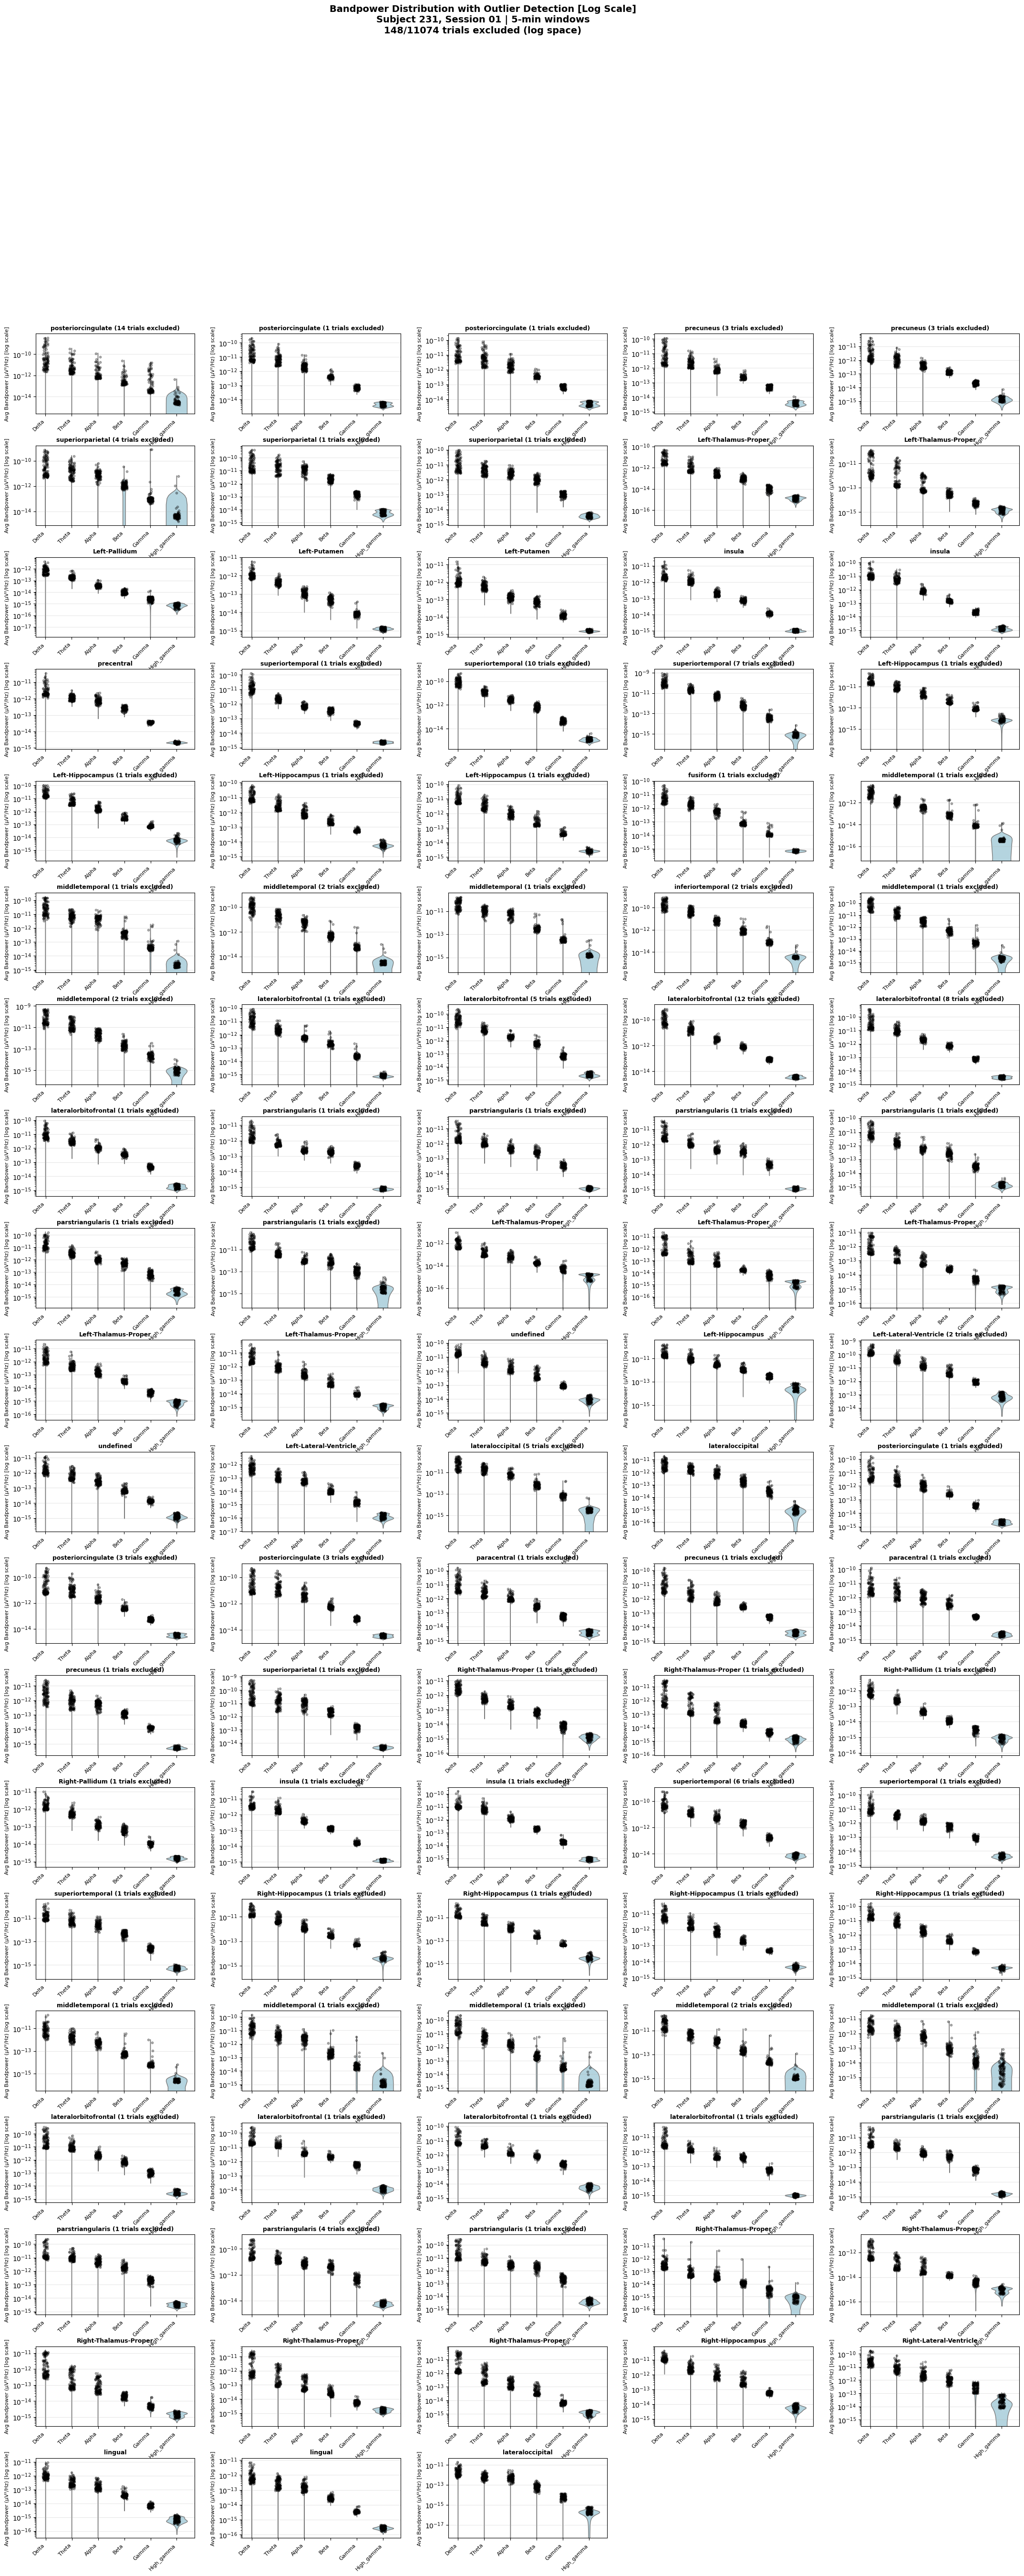

In [6]:
# Highlight outliers (don't exclude)
plot_channel_bandpower_with_outliers(
    all_channel_band_data=all_channel_band_data,
    electrode_labels=electrode_labels,
    subject_id=subject_id,
    session_id=session_id,
    output_dir='plot/',
    outlier_std_threshold=4.0,
    exclude_outliers=False,
    log_scale=True,
    detect_outliers_in_log_space=True# Just highlight in pink
)

# Exclude outliers completely
plot_channel_bandpower_with_outliers(
    all_channel_band_data=all_channel_band_data,
    electrode_labels=electrode_labels,
    subject_id=subject_id,
    session_id=session_id,
    output_dir='plot/',
    outlier_std_threshold=4.0,
    log_scale=True,
    detect_outliers_in_log_space=True,# Just highlight in pink
    exclude_outliers=True  # Remove from plot entirely
)

In [ ]:
# Step 2: Plot with different parameters without reloading
if all_channel_band_data is not None:
    # First plot - all channels, 3 per row
    plot_channel_bandpower_vs_pain(
        all_channel_band_data=all_channel_band_data,
        electrode_labels=electrode_labels,
        subject_id=subject_id,
        session_id=session_id,
        output_dir='plot/',
        window_minutes=5,
        band_names=['delta', 'theta', 'alpha', 'beta', 'gamma', 'high_gamma'],
        n_channels_to_plot=50,
        subplots_per_row=5,
        jitter_amount=0.25
    )

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pynwb import NWBHDF5IO
from pathlib import Path
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

def get_nwb_files(subject_id: str, session_id: str, 
                  base_path: str = '/oak/stanford/groups/ckeller1/data/iEEG_EHR/iEEG_NWB') -> List[Path]:
    """Get all preprocessed NWB files for a given subject and session."""
    preprocessed_dir = Path(base_path) / f'sub-{subject_id}' / f'ses-{session_id}' / 'preprocessed'
    nwb_files = sorted(preprocessed_dir.glob('*_bipolar_psd.nwb'))
    print(f"Found {len(nwb_files)} NWB files in {preprocessed_dir}")
    return nwb_files

def load_pain_scores(subject_id: str, session_id: str, 
                     base_path: str = '/oak/stanford/groups/ckeller1/data/iEEG_EHR/iEEG_NWB') -> pd.DataFrame:
    """Load pain scores from EHR folder."""
    ehr_dir = Path(base_path) / f'sub-{subject_id}' / f'ses-{session_id}' / 'ehr'
    pain_file = ehr_dir / f'sub-{subject_id}_ses-{session_id}_pain-scores.csv'
    
    if not pain_file.exists():
        raise FileNotFoundError(f"Pain scores file not found: {pain_file}")
    
    # Load pain scores
    pain_df = pd.read_csv(pain_file)
    
    # Convert date column to datetime
    pain_df['date'] = pd.to_datetime(pain_df['date'])
    
    # Filter for this specific subject and session
    pain_df = pain_df[(pain_df['sub_id'] == f'sub-{subject_id}') & 
                      (pain_df['ses_id'] == f'ses-{session_id}')]
    
    print(f"Loaded {len(pain_df)} pain scores for sub-{subject_id}, ses-{session_id}")
    
    return pain_df

def load_electrode_labels(nwb_file_path: Path) -> Dict[int, str]:
    """Load electrode labels from NWB file."""
    electrode_labels = {}
    try:
        with NWBHDF5IO(str(nwb_file_path), 'r') as io:
            nwb = io.read()
            electrodes_df = nwb.electrodes.to_dataframe()
            
            if 'Desikan_Killiany_cathode' in electrodes_df.columns:
                for idx, row in electrodes_df.iterrows():
                    label = row['Desikan_Killiany_cathode']
                    # Handle NaN or empty labels
                    if pd.isna(label) or label == '' or label == 'nan':
                        electrode_labels[idx] = f'Ch{idx}'
                    else:
                        electrode_labels[idx] = str(label)
                print(f"Loaded electrode labels for {len(electrode_labels)} channels")
            else:
                print("Warning: 'Desikan_Killiany_cathode' column not found")
                print(f"Available columns: {list(electrodes_df.columns)}")
    except Exception as e:
        print(f"Warning: Could not load electrode labels: {e}")
    
    return electrode_labels

def filter_valid_channels(electrode_labels: Dict[int, str]) -> Dict[int, str]:
    """
    Filter out channels with 'unknown' or 'white-matter' in their labels.
    
    Returns:
        Dictionary of valid electrode labels (filtered)
    """
    valid_labels = {}
    filtered_count = 0
    
    for ch_idx, label in electrode_labels.items():
        label_lower = label.lower()
        # Check if label contains 'unknown' or 'white-matter' (or 'white matter')
        if 'unknown' in label_lower or 'white-matter' in label_lower or 'white matter' in label_lower:
            filtered_count += 1
            continue
        valid_labels[ch_idx] = label
    
    print(f"Filtered out {filtered_count} channels (unknown/white-matter)")
    print(f"Remaining valid channels: {len(valid_labels)}")
    
    return valid_labels

def extract_bandpower_windows(nwb_file: Path, pain_df: pd.DataFrame, 
                              window_minutes: int = 5, 
                              band_names: List[str] = ['delta', 'theta', 'alpha', 'beta', 'gamma', 'high_gamma']) -> Dict:
    """
    Extract bandpower for 5-minute windows before each pain score, along with the pain score value.
    
    Returns:
        dict: {channel_idx: {band_name: [(bandpower, pain_score), ...]}}
    """
    channel_band_data = {}
    
    try:
        with NWBHDF5IO(str(nwb_file), 'r') as io:
            nwb = io.read()
            
            # Get session start time
            session_start = nwb.session_start_time
            
            # Load band power data
            band_power_series = nwb.processing['ecephys']["band_power"]
            band_power_data = band_power_series.data[:]  # Shape: (timepoints, channels, bands)
            
            # Get timestamps
            if band_power_series.timestamps is not None:
                band_power_timestamps = band_power_series.timestamps[:]
            else:
                # Reconstruct timestamps from starting_time and rate
                starting_time = band_power_series.starting_time
                rate = band_power_series.rate
                n_timepoints = band_power_data.shape[0]
                band_power_timestamps = starting_time + np.arange(n_timepoints) / rate
            
            # Convert timestamps to datetime (relative to session start)
            band_power_datetimes = pd.to_datetime(session_start) + pd.to_timedelta(band_power_timestamps, unit='s')
            
            # Remove timezone info to match pain timestamps
            band_power_datetimes = band_power_datetimes.tz_localize(None)
            
            # Iterate through each pain event
            events_found = 0
            for idx, row in pain_df.iterrows():
                pain_time = row['date']
                pain_score = row['max_pain']
                
                # Skip if pain score is NaN
                if pd.isna(pain_score):
                    continue
                
                # Calculate window start time (5 minutes before pain score)
                window_start = pain_time - pd.Timedelta(minutes=window_minutes)
                
                # Find indices within the 5-minute window
                mask = (band_power_datetimes >= window_start) & (band_power_datetimes < pain_time)
                
                if not np.any(mask):
                    continue
                
                events_found += 1
                
                # Get data for this window
                window_data = band_power_data[mask, :, :]  # Shape: (time_in_window, channels, bands)
                
                # Average across time for each channel and band
                mean_bandpower = np.mean(window_data, axis=0)  # Shape: (channels, bands)
                
                # Store data organized by channel and band, including pain score
                n_channels = mean_bandpower.shape[0]
                for ch_idx in range(n_channels):
                    if ch_idx not in channel_band_data:
                        channel_band_data[ch_idx] = {band: [] for band in band_names}
                    
                    for band_idx, band_name in enumerate(band_names):
                        channel_band_data[ch_idx][band_name].append(
                            (mean_bandpower[ch_idx, band_idx], pain_score)
                        )
            
    except Exception as e:set_yscale
        print(f"  Error processing {nwb_file.name}: {e}")
        return {}
    
    return channel_band_data

def load_session_data(subject_id: str, session_id: str,
                     window_minutes: int = 5,
                     band_names: List[str] = ['delta', 'theta', 'alpha', 'beta', 'gamma', 'high_gamma'],
                     filter_channels: bool = True) -> Tuple[Dict, Dict[int, str], pd.DataFrame]:
    """
    Load all data for a session - separates data loading from plotting.
    
    Args:
        filter_channels: If True, filters out channels with 'unknown' or 'white-matter' labels
    
    Returns:
        Tuple of (all_channel_band_data, electrode_labels, summary_dataframe)
    """
    print(f"\n{'='*60}")
    print(f"Loading Data for Subject {subject_id}, Session {session_id}")
    print(f"{'='*60}\n")
    
    # Load pain scores
    pain_df = load_pain_scores(subject_id, session_id)
    
    if len(pain_df) == 0:
        print("No pain scores found!")
        return None, None, None
    
    # Get all NWB files
    nwb_files = get_nwb_files(subject_id, session_id)
    
    if len(nwb_files) == 0:
        print("No NWB files found!")
        return None, None, None
    
    # Load electrode labels from first NWB file
    print("\nLoading electrode labels...")
    electrode_labels = load_electrode_labels(nwb_files[0])
    
    # Filter channels if requested
    if filter_channels:
        print("\nFiltering channels...")
        electrode_labels = filter_valid_channels(electrode_labels)
        valid_channel_indices = set(electrode_labels.keys())
    else:
        valid_channel_indices = None
    
    # Collect bandpower data across all runs
    all_channel_band_data = {}
    
    print(f"\nExtracting {window_minutes}-minute windows before pain scores...")
    print(f"Processing {len(nwb_files)} files (progress updates every 10 files)...")
    
    for file_idx, nwb_file in enumerate(nwb_files):
        if (file_idx + 1) % 10 == 0 or (file_idx + 1) == len(nwb_files):
            print(f"  Processed {file_idx + 1}/{len(nwb_files)} files...")
        
        file_data = extract_bandpower_windows(nwb_file, pain_df, window_minutes, band_names)
        
        # Merge with overall data (only for valid channels if filtering)
        for ch_idx, band_dict in file_data.items():
            # Skip filtered channels
            if valid_channel_indices is not None and ch_idx not in valid_channel_indices:
                continue
                
            if ch_idx not in all_channel_band_data:
                all_channel_band_data[ch_idx] = {band: [] for band in band_names}
            
            for band_name, values in band_dict.items():
                all_channel_band_data[ch_idx][band_name].extend(values)
    
    # Create summary DataFrame
    summary_data = []
    for ch_idx, band_dict in all_channel_band_data.items():
        for band_name, values in band_dict.items():
            for bandpower, pain_score in values:
                summary_data.append({
                    'Channel': ch_idx,
                    'Channel_Label': electrode_labels.get(ch_idx, f'Ch{ch_idx}'),
                    'Band': band_name,
                    'Bandpower': bandpower,
                    'PainScore': pain_score
                })
    
    df_summary = pd.DataFrame(summary_data)
    
    print(f"\n{'='*60}")
    print(f"Data loading complete!")
    print(f"Total data points: {len(df_summary)}")
    print(f"Channels: {len(all_channel_band_data)}")
    print(f"{'='*60}\n")
    
    return all_channel_band_data, electrode_labels, df_summary

def plot_channel_bandpower_separate_pain(all_channel_band_data: Dict,
                                         electrode_labels: Dict[int, str],
                                         subject_id: str, 
                                         session_id: str,
                                         output_dir: str = './plots',
                                         window_minutes: int = 5,
                                         band_names: List[str] = ['delta', 'theta', 'alpha', 'beta', 'gamma', 'high_gamma'],
                                         n_channels_to_plot: int = None,
                                         subplots_per_row: int = 5,
                                         pain_threshold: float = 5.0,
                                         jitter_amount: float = 0.15):
    """
    Create scatter plots with low pain and high pain separated into different columns.
    Each frequency band gets two columns: one for low pain, one for high pain.
    """
    
    # Determine which channels to plot
    available_channels = [ch for ch in all_channel_band_data.keys() if ch in electrode_labels]
    channels_to_plot = sorted(available_channels)
    
    if n_channels_to_plot is not None:
        channels_to_plot = channels_to_plot[:n_channels_to_plot]
    
    n_channels = len(channels_to_plot)
    if n_channels == 0:
        print("No channels to plot!")
        return
    
    # Calculate grid dimensions - now we have 2x the bands (low and high for each)
    n_band_cols = len(band_names) * 2  # Two columns per band
    n_cols = subplots_per_row
    n_rows = int(np.ceil(n_channels / n_cols))
    
    # Create figure with extra space on the right for colorbar
    fig_width = n_cols * 5 + 1.5
    fig_height = n_rows * 3
    fig = plt.figure(figsize=(fig_width, fig_height))
    
    # Create grid spec with space for colorbar
    gs = fig.add_gridspec(n_rows, n_cols + 1, width_ratios=[1]*n_cols + [0.05], 
                          wspace=0.3, hspace=0.4, right=0.95)
    
    print(f"\nCreating plots for {n_channels} channels...")
    print(f"Pain threshold: ≤{pain_threshold} (low) vs >{pain_threshold} (high)")
    
    # Plot each channel
    for plot_idx, ch_idx in enumerate(channels_to_plot):
        row = plot_idx // n_cols
        col = plot_idx % n_cols
        ax = fig.add_subplot(gs[row, col])
        
        # Prepare x-axis positions and labels
        x_positions = []
        x_labels = []
        
        for band_idx, band_name in enumerate(band_names):
            x_positions.extend([band_idx * 2, band_idx * 2 + 1])
            x_labels.extend([f'{band_name.capitalize()}\nLow', f'{band_name.capitalize()}\nHigh'])
        
        # Collect and plot data for this channel
        for band_idx, band_name in enumerate(band_names):
            if band_name not in all_channel_band_data[ch_idx]:
                continue
            
            data_points = all_channel_band_data[ch_idx][band_name]
            
            if len(data_points) == 0:
                continue
            
            # Separate into low and high pain
            low_pain_bp = [bp for bp, ps in data_points if ps <= pain_threshold]
            high_pain_bp = [bp for bp, ps in data_points if ps > pain_threshold]
            
            # Plot low pain (left column for this band)
            if len(low_pain_bp) > 0:
                x_low = band_idx * 2 + np.random.uniform(-jitter_amount, jitter_amount, len(low_pain_bp))
                ax.scatter(x_low, low_pain_bp, c='blue', alpha=0.5, s=30, 
                          edgecolors='black', linewidths=0.5, label='Low Pain' if band_idx == 0 else '')
            
            # Plot high pain (right column for this band)
            if len(high_pain_bp) > 0:
                x_high = band_idx * 2 + 1 + np.random.uniform(-jitter_amount, jitter_amount, len(high_pain_bp))
                ax.scatter(x_high, high_pain_bp, c='red', alpha=0.5, s=30, 
                          edgecolors='black', linewidths=0.5, label='High Pain' if band_idx == 0 else '')
        
        # Formatting
        ax.set_xticks(range(len(x_labels)))
        ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=6)
        ax.set_ylabel('Avg Bandpower (μV²/Hz)', fontsize=8)
        
        # Use electrode label
        title = electrode_labels[ch_idx]
        ax.set_title(title, fontsize=9, fontweight='bold')
        
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_xlim(-0.5, len(x_labels) - 0.5)
        
        # Add legend only to first subplot
        if plot_idx == 0:
            ax.legend(loc='upper right', fontsize=7)
    
    # Overall title
    fig.suptitle(f'Bandpower: Low Pain (≤{pain_threshold}) vs High Pain (>{pain_threshold})\n' +
                 f'Subject {subject_id}, Session {session_id} | {window_minutes}-min windows before pain scores',
                 fontsize=14, fontweight='bold', y=0.995)
    
    # Save plot
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    output_file = Path(output_dir) / f'sub-{subject_id}_ses-{session_id}_bandpower_low_vs_high_pain.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"\nSaved: {output_file}")
    plt.show()
    plt.close()

def plot_per_band_low_vs_high(all_channel_band_data: Dict,
                               electrode_labels: Dict[int, str],
                               subject_id: str, 
                               session_id: str,
                               output_dir: str = './plots',
                               window_minutes: int = 5,
                               band_names: List[str] = ['delta', 'theta', 'alpha', 'beta', 'gamma', 'high_gamma'],
                               n_channels_to_plot: int = None,
                               subplots_per_row: int = 5,
                               pain_threshold: float = 5.0,
                               jitter_amount: float = 0.2):
    """
    Create separate figures for each frequency band.
    Each subplot shows one channel with two columns: low pain and high pain.
    """
    
    # Determine which channels to plot
    available_channels = [ch for ch in all_channel_band_data.keys() if ch in electrode_labels]
    channels_to_plot = sorted(available_channels)
    
    if n_channels_to_plot is not None:
        channels_to_plot = channels_to_plot[:n_channels_to_plot]
    
    n_channels = len(channels_to_plot)
    if n_channels == 0:
        print("No channels to plot!")
        return
    
    print(f"\nCreating per-band plots for {n_channels} channels...")
    print(f"Pain threshold: ≤{pain_threshold} (low) vs >{pain_threshold} (high)")
    
    # Create one figure per frequency band
    for band_name in band_names:
        # Calculate grid dimensions
        n_cols = subplots_per_row
        n_rows = int(np.ceil(n_channels / n_cols))
        
        # Create figure
        fig_width = n_cols * 3.5
        fig_height = n_rows * 3
        fig, axes = plt.subplots(nset_yscale_rows, n_cols, figsize=(fig_width, fig_height))
        
        # Flatten axes array for easier iteration
        if n_channels == 1:
            axes = np.array([axes])
        else:
            axes = axes.flatten()
        
        # Plot each channel
        for plot_idx, ch_idx in enumerate(channels_to_plot):
            ax = axes[plot_idx]
            
            if band_name not in all_channel_band_data[ch_idx]:
                ax.axis('off')
                continue
            
            data_points = all_channel_band_data[ch_idx][band_name]
            
            if len(data_points) == 0:
                ax.axis('off')
                continue
            
            # Separate into low and high pain
            low_pain_bp = [bp for bp, ps in data_points if ps <= pain_threshold]
            high_pain_bp = [bp for bp, ps in data_points if ps > pain_threshold]
            
            # Plot low pain (position 0)
            if len(low_pain_bp) > 0:
                x_low = np.random.uniform(-jitter_amount, jitter_amount, len(low_pain_bp))
                ax.scatter(x_low, low_pain_bp, c='blue', alpha=0.5, s=40, 
                          edgecolors='black', linewidths=0.5, label=f'Low (n={len(low_pain_bp)})')
            
            # Plot high pain (position 1)
            if len(high_pain_bp) > 0:
                x_high = 1 + np.random.uniform(-jitter_amount, jitter_amount, len(high_pain_bp))
                ax.scatter(x_high, high_pain_bp, c='red', alpha=0.5, s=40, 
                          edgecolors='black', linewidths=0.5, label=f'High (n={len(high_pain_bp)})')
            
            # Formatting
            ax.set_xticks([0, 1])
            ax.set_xticklabels([f'Low\n(≤{pain_threshold})', f'High\n(>{pain_threshold})'], fontsize=8)
            ax.set_ylabel('Avg Bandpower (μV²/Hz)', fontsize=8)
            
            # Use electrode label
            title = electrode_labels[ch_idx]
            ax.set_title(title, fontsize=9, fontweight='bold')
            
            ax.grid(True, alpha=0.3, axis='y')
            ax.set_xlim(-0.5, 1.5set_yscale)
            ax.legend(loc='upper right', fontsize=6)
        
        # Remove empty subplots
        for idx in range(n_channels, len(axes)):
            fig.delaxes(axes[idx])
        
        # Overall title
        fig.suptitle(f'{band_name.capitalize()} Band: Low vs High Pain\n' +
                     f'Subject {subject_id}, Session {session_id} | {window_minutes}-min windows',
                     fontsize=14, fontweight='bold')
        
        plt.tight_layout()
        
        # Save plot
        Path(output_dir).mkdir(parents=True, exist_ok=True)
        output_file = Path(output_dir) / f'sub-{subject_id}_ses-{session_id}_{band_name}_low_vs_high_pain.png'
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"Saved: {output_file.name}")
        plt.close()

# ============================================================================
# USAGE
# ============================================================================

# Load data once
subject_id = '256'
session_id = '01'

all_channel_band_data, electrode_labels, df_summary = load_session_data(
    subject_id=subject_id,
    session_id=session_id,
    window_minutes=5,
    band_names=['delta', 'theta', 'alpha', 'beta', 'gamma', 'high_gamma'],
    filter_channels=True
)

if all_channel_band_data is not None:
    # Option 1: All bands in one figure with low/high separated
    plot_channel_bandpower_separate_pain(
        all_channel_band_data=all_channel_band_data,
        electrode_labels=electrode_labels,
        subject_id=subject_id,
        session_id=session_id,
        output_dir='plot/',
        window_minutes=5,
        band_names=['delta', 'theta', 'alpha', 'beta', 'gamma', 'high_gamma'],
        n_channels_to_plot=None,
        subplots_per_row=3,
        pain_threshold=5.0,
        jitter_amount=0.15
    )
    
    # Option 2: Separate figure for each band
    plot_per_band_low_vs_high(
        all_channel_band_data=all_channel_band_data,
        electrode_labels=electrode_labels,
        subject_id=subject_id,
        session_id=session_id,
        output_dir='plot/',
        window_minutes=5,
        band_names=['delta', 'theta', 'alpha', 'beta', 'gamma', 'high_gamma'],
        n_channels_to_plot=None,
        subplots_per_row=5,
        pain_threshold=5.0,
        jitter_amount=0.2
    )

In [ ]:
def plot_channel_bandpower_separate_pain(all_channel_band_data: Dict,
                                         electrode_labels: Dict[int, str],
                                         subject_id: str, 
                                         session_id: str,
                                         output_dir: str = './plots',
                                         window_minutes: int = 5,
                                         band_names: List[str] = ['delta', 'theta', 'alpha', 'beta', 'gamma', 'high_gamma'],
                                         n_channels_to_plot: int = None,
                                         subplots_per_row: int = 5,
                                         pain_threshold: float = 5.0):
    """
    Create violin plots with low pain and high pain separated into different columns.
    Each frequency band gets two columns: one for low pain, one for high pain.
    """
    
    # Determine which channels to plot
    available_channels = [ch for ch in all_channel_band_data.keys() if ch in electrode_labels]
    channels_to_plot = sorted(available_channels)
    
    if n_channels_to_plot is not None:
        channels_to_plot = channels_to_plot[:n_channels_to_plot]
    
    n_channels = len(channels_to_plot)
    if n_channels == 0:
        print("No channels to plot!")
        return
    
    # Calculate grid dimensions
    n_cols = subplots_per_row
    n_rows = int(np.ceil(n_channels / n_cols))
    
    # Create figure
    fig_width = n_cols * 5 + 1.5
    fig_height = n_rows * 3
    fig = plt.figure(figsize=(fig_width, fig_height))
    
    # Create grid spec
    gs = fig.add_gridspec(n_rows, n_cols, wspace=0.3, hspace=0.4, right=0.95)
    
    print(f"\nCreating violin plots for {n_channels} channels...")
    print(f"Pain threshold: ≤{pain_threshold} (low) vs >{pain_threshold} (high)")
    
    # Plot each channel
    for plot_idx, ch_idx in enumerate(channels_to_plot):
        row = plot_idx // n_cols
        col = plot_idx % n_cols
        ax = fig.add_subplot(gs[row, col])
        
        # Prepare data for violin plot
        plot_data = []
        
        for band_name in band_names:
            if band_name not in all_channel_band_data[ch_idx]:
                continue
            
            data_points = all_channel_band_data[ch_idx][band_name]
            
            if len(data_points) == 0:
                continue
            
            # Separate into low and high pain
            for bp, ps in data_points:
                pain_level = 'Low' if ps <= pain_threshold else 'High'
                plot_data.append({
                    'Band': band_name.capitalize(),
                    'Pain Level': pain_level,
                    'Bandpower': bp,
                    'Band_Pain': f'{band_name.capitalize()}\n{pain_level}'
                })
        
        if len(plot_data) == 0:
            ax.axis('off')
            continue
        
        df_plot = pd.DataFrame(plot_data)
        
        # Create violin plot
        sns.violinplot(data=df_plot, x='Band_Pain', y='Bandpower', 
                      hue='Pain Level', ax=ax, palette={'Low': 'blue', 'High': 'red'},
                      split=False, inner='box', linewidth=1)
        
        # Formatting
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=6)
        ax.set_xlabel('')
        ax.set_ylabel('Avg Bandpower (μV²/Hz)', fontsize=8)
        
        # Use electrode label
        title = electrode_labels[ch_idx]
        ax.set_title(title, fontsize=9, fontweight='bold')
        
        ax.grid(True, alpha=0.3, axis='y')
        
        # Only show legend on first subplot
        if plot_idx == 0:
            ax.legend(loc='upper right', fontsize=7, title='Pain Level')
        else:
            ax.get_legend().remove()
    
    # Overall title
    fig.suptitle(f'Bandpower: Low Pain (≤{pain_threshold}) vs High Pain (>{pain_threshold})\n' +
                 f'Subject {subject_id}, Session {session_id} | {window_minutes}-min windows before pain scores',
                 fontsize=14, fontweight='bold', y=0.995)
    
    # Save plot
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    output_file = Path(output_dir) / f'sub-{subject_id}_ses-{session_id}_bandpower_low_vs_high_pain_violin.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"\nSaved: {output_file}")
    plt.show()
    plt.close()

def plot_per_band_low_vs_high(all_channel_band_data: Dict,
                               electrode_labels: Dict[int, str],
                               subject_id: str, 
                               session_id: str,
                               output_dir: str = './plots',
                               window_minutes: int = 5,
                               band_names: List[str] = ['delta', 'theta', 'alpha', 'beta', 'gamma', 'high_gamma'],
                               n_channels_to_plot: int = None,
                               subplots_per_row: int = 5,
                               pain_threshold: float = 5.0):
    """
    Create separate figures for each frequency band with violin plots.
    Each subplot shows one channel with two columns: low pain and high pain.
    """
    
    # Determine which channels to plot
    available_channels = [ch for ch in all_channel_band_data.keys() if ch in electrode_labels]
    channels_to_plot = sorted(available_channels)
    
    if n_channels_to_plot is not None:
        channels_to_plot = channels_to_plot[:n_channels_to_plot]
    
    n_channels = len(channels_to_plot)
    if n_channels == 0:
        print("No channels to plot!")
        return
    
    print(f"\nCreating per-band violin plots for {n_channels} channels...")
    print(f"Pain threshold: ≤{pain_threshold} (low) vs >{pain_threshold} (high)")
    
    # Create one figure per frequency band
    for band_name in band_names:
        # Calculate grid dimensions
        n_cols = subplots_per_row
        n_rows = int(np.ceil(n_channels / n_cols))
        
        # Create figure
        fig_width = n_cols * 3.5
        fig_height = n_rows * 3
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height))
        
        # Flatten axes array for easier iteration
        if n_channels == 1:
            axes = np.array([axes])
        else:
            axes = axes.flatten()
        
        # Plot each channel
        for plot_idx, ch_idx in enumerate(channels_to_plot):
            ax = axes[plot_idx]
            
            if band_name not in all_channel_band_data[ch_idx]:
                ax.axis('off')
                continue
            
            data_points = all_channel_band_data[ch_idx][band_name]
            
            if len(data_points) == 0:
                ax.axis('off')
                continue
            
            # Prepare data for violin plot
            plot_data = []
            for bp, ps in data_points:
                pain_level = 'Low' if ps <= pain_threshold else 'High'
                plot_data.append({
                    'Pain Level': pain_level,
                    'Bandpower': bp
                })
            
            df_plot = pd.DataFrame(plot_data)
            
            # Check if we have data for both levels
            low_count = len(df_plot[df_plot['Pain Level'] == 'Low'])
            high_count = len(df_plot[df_plot['Pain Level'] == 'High'])
            
            if low_count == 0 or high_count == 0:
                # If only one level, use a simple plot
                ax.axis('off')
                continue
            
            # Create violin plot
            sns.violinplot(data=df_plot, x='Pain Level', y='Bandpower', 
                          ax=ax, palette={'Low': 'blue', 'High': 'red'},
                          order=['Low', 'High'], inner='box', linewidth=1)
            
            # Formatting
            ax.set_xticklabels([f'Low\n(≤{pain_threshold})\nn={low_count}', 
                               f'High\n(>{pain_threshold})\nn={high_count}'], fontsize=8)
            ax.set_xlabel('')
            ax.set_ylabel('Avg Bandpower (μV²/Hz)', fontsize=8)
            
            # Use electrode label
            title = electrode_labels[ch_idx]
            ax.set_title(title, fontsize=9, fontweight='bold')
            
            ax.grid(True, alpha=0.3, axis='y')
        
        # Remove empty subplots
        for idx in range(n_channels, len(axes)):
            fig.delaxes(axes[idx])
        
        # Overall title
        fig.suptitle(f'{band_name.capitalize()} Band: Low vs High Pain\n' +
                     f'Subject {subject_id}, Session {session_id} | {window_minutes}-min windows',
                     fontsize=14, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        # Save plot
        Path(output_dir).mkdir(parents=True, exist_ok=True)
        output_file = Path(output_dir) / f'sub-{subject_id}_ses-{session_id}_{band_name}_low_vs_high_pain_violin.png'
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"Saved: {output_file.name}")
        plt.close()

In [ ]:
median_pain = df_summary['PainScore'].median()
print(median_pain)

In [ ]:
if all_channel_band_data is not None:
    # Option 1: All bands in one figure with low/high separated

    
    # Option 2: Separate figure for each band
    plot_per_band_low_vs_high(
        all_channel_band_data=all_channel_band_data,
        electrode_labels=electrode_labels,
        subject_id=subject_id,
        session_id=session_id,
        output_dir='plot/',
        window_minutes=5,
        band_names=['delta', 'theta', 'alpha', 'beta', 'gamma', 'high_gamma'],
        n_channels_to_plot=None,
        subplots_per_row=5,
        pain_threshold=median_pain)

In [7]:
def plot_channel_bandpower_quartiles(all_channel_band_data: Dict,
                                     electrode_labels: Dict[int, str],
                                     subject_id: str, 
                                     session_id: str,
                                     output_dir: str = './plots',
                                     window_minutes: int = 5,
                                     band_names: List[str] = ['delta', 'theta', 'alpha', 'beta', 'gamma', 'high_gamma'],
                                     n_channels_to_plot: int = None,
                                     subplots_per_row: int = 5,
                                     log_scale: bool = False):
    """
    Create violin plots with pain scores split into quartiles (Q1, Q2, Q3, Q4).
    Each frequency band shows four quartiles.
    """
    
    # Determine which channels to plot
    available_channels = [ch for ch in all_channel_band_data.keys() if ch in electrode_labels]
    channels_to_plot = sorted(available_channels)
    
    if n_channels_to_plot is not None:
        channels_to_plot = channels_to_plot[:n_channels_to_plot]
    
    n_channels = len(channels_to_plot)
    if n_channels == 0:
        print("No channels to plot!")
        return
    
    # Calculate quartile thresholds from all pain scores
    all_pain_scores = []
    for ch_idx in all_channel_band_data.keys():
        for band_name in band_names:
            if band_name in all_channel_band_data[ch_idx]:
                for _, pain_score in all_channel_band_data[ch_idx][band_name]:
                    all_pain_scores.append(pain_score)
    
    q1_thresh = np.percentile(all_pain_scores, 25)
    q2_thresh = np.percentile(all_pain_scores, 50)
    q3_thresh = np.percentile(all_pain_scores, 75)
    
    print(f"\nPain score quartile thresholds:")
    print(f"  Q1: ≤{q1_thresh:.1f}")
    print(f"  Q2: {q1_thresh:.1f} < pain ≤ {q2_thresh:.1f}")
    print(f"  Q3: {q2_thresh:.1f} < pain ≤ {q3_thresh:.1f}")
    print(f"  Q4: >{q3_thresh:.1f}")
    
    def assign_quartile(pain_score):
        if pain_score <= q1_thresh:
            return 'Q1'
        elif pain_score <= q2_thresh:
            return 'Q2'
        elif pain_score <= q3_thresh:
            return 'Q3'
        else:
            return 'Q4'
    
    # Calculate grid dimensions
    n_cols = subplots_per_row
    n_rows = int(np.ceil(n_channels / n_cols))
    
    # Create figure
    fig_width = n_cols * 6
    fig_height = n_rows * 3
    fig = plt.figure(figsize=(fig_width, fig_height))
    
    # Create grid spec
    gs = fig.add_gridspec(n_rows, n_cols, wspace=0.3, hspace=0.4, right=0.95)
    
    print(f"\nCreating violin plots for {n_channels} channels...")
    
    # Plot each channel
    for plot_idx, ch_idx in enumerate(channels_to_plot):
        row = plot_idx // n_cols
        col = plot_idx % n_cols
        ax = fig.add_subplot(gs[row, col])
        
        # Prepare data for violin plot
        plot_data = []
        
        for band_name in band_names:
            if band_name not in all_channel_band_data[ch_idx]:
                continue
            
            data_points = all_channel_band_data[ch_idx][band_name]
            
            if len(data_points) == 0:
                continue
            
            # Assign quartiles
            for bp, ps in data_points:
                quartile = assign_quartile(ps)
                plot_data.append({
                    'Band': band_name.capitalize(),
                    'Quartile': quartile,
                    'Bandpower': bp,
                    'Band_Quartile': f'{band_name.capitalize()}\n{quartile}'
                })
        
        if len(plot_data) == 0:
            ax.axis('off')
            continue
        
        df_plot = pd.DataFrame(plot_data)
        
        # Create violin plot with color gradient for quartiles
        quartile_colors = {'Q1': '#2166ac', 'Q2': '#92c5de', 'Q3': '#f4a582', 'Q4': '#b2182b'}
        
        sns.violinplot(data=df_plot, x='Band_Quartile', y='Bandpower', 
                      hue='Quartile', ax=ax, palette=quartile_colors,
                      hue_order=['Q1', 'Q2', 'Q3', 'Q4'],
                      split=False, inner='box', linewidth=1)
        
        # Set log scale if requested
        if log_scale:
            ax.set_yscale('log')
        
        # Formatting
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=6)
        ax.set_xlabel('')
        ax.set_ylabel('Avg Bandpower (μV²/Hz)' + (' [log scale]' if log_scale else ''), fontsize=8)
        
        # Use electrode label
        title = electrode_labels[ch_idx]
        ax.set_title(title, fontsize=9, fontweight='bold')
        
        ax.grid(True, alpha=0.3, axis='y')
        
        # Only show legend on first subplot
        if plot_idx == 0:
            ax.legend(loc='upper right', fontsize=7, title='Pain Quartile')
        else:
            ax.get_legend().remove()
    
    # Overall title
    scale_text = ' [Log Scale]' if log_scale else ''
    fig.suptitle(f'Bandpower by Pain Score Quartiles{scale_text}\n' +
                 f'Subject {subject_id}, Session {session_id} | {window_minutes}-min windows before pain scores',
                 fontsize=14, fontweight='bold', y=0.995)
    
    # Save plot
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    filename_suffix = '_log' if log_scale else ''
    output_file = Path(output_dir) / f'sub-{subject_id}_ses-{session_id}_bandpower_quartiles_violin{filename_suffix}.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"\nSaved: {output_file}")
    plt.show()
    plt.close()

def plot_per_band_quartiles(all_channel_band_data: Dict,
                            electrode_labels: Dict[int, str],
                            subject_id: str, 
                            session_id: str,
                            output_dir: str = './plots',
                            window_minutes: int = 5,
                            band_names: List[str] = ['delta', 'theta', 'alpha', 'beta', 'gamma', 'high_gamma'],
                            n_channels_to_plot: int = None,
                            subplots_per_row: int = 5,
                            log_scale: bool = False):
    """
    Create separate figures for each frequency band with violin plots.
    Each subplot shows one channel with four columns: Q1, Q2, Q3, Q4.
    """
    
    # Determine which channels to plot
    available_channels = [ch for ch in all_channel_band_data.keys() if ch in electrode_labels]
    channels_to_plot = sorted(available_channels)
    
    if n_channels_to_plot is not None:
        channels_to_plot = channels_to_plot[:n_channels_to_plot]
    
    n_channels = len(channels_to_plot)
    if n_channels == 0:
        print("No channels to plot!")
        return
    
    # Calculate quartile thresholds from all pain scores
    all_pain_scores = []
    for ch_idx in all_channel_band_data.keys():
        for band_name in band_names:
            if band_name in all_channel_band_data[ch_idx]:
                for _, pain_score in all_channel_band_data[ch_idx][band_name]:
                    all_pain_scores.append(pain_score)
    
    q1_thresh = np.percentile(all_pain_scores, 25)
    q2_thresh = np.percentile(all_pain_scores, 50)
    q3_thresh = np.percentile(all_pain_scores, 75)
    
    print(f"\nPain score quartile thresholds:")
    print(f"  Q1: ≤{q1_thresh:.1f}")
    print(f"  Q2: {q1_thresh:.1f} < pain ≤ {q2_thresh:.1f}")
    print(f"  Q3: {q2_thresh:.1f} < pain ≤ {q3_thresh:.1f}")
    print(f"  Q4: >{q3_thresh:.1f}")
    
    def assign_quartile(pain_score):
        if pain_score <= q1_thresh:
            return 'Q1'
        elif pain_score <= q2_thresh:
            return 'Q2'
        elif pain_score <= q3_thresh:
            return 'Q3'
        else:
            return 'Q4'
    
    print(f"\nCreating per-band violin plots for {n_channels} channels...")
    
    # Create one figure per frequency band
    for band_name in band_names:
        # Calculate grid dimensions
        n_cols = subplots_per_row
        n_rows = int(np.ceil(n_channels / n_cols))
        
        # Create figure
        fig_width = n_cols * 4
        fig_height = n_rows * 3
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height))
        
        # Flatten axes array for easier iteration
        if n_channels == 1:
            axes = np.array([axes])
        else:
            axes = axes.flatten()
        
        # Plot each channel
        for plot_idx, ch_idx in enumerate(channels_to_plot):
            ax = axes[plot_idx]
            
            if band_name not in all_channel_band_data[ch_idx]:
                ax.axis('off')
                continue
            
            data_points = all_channel_band_data[ch_idx][band_name]
            
            if len(data_points) == 0:
                ax.axis('off')
                continue
            
            # Prepare data for violin plot
            plot_data = []
            for bp, ps in data_points:
                quartile = assign_quartile(ps)
                plot_data.append({
                    'Quartile': quartile,
                    'Bandpower': bp
                })
            
            df_plot = pd.DataFrame(plot_data)
            
            # Count samples in each quartile
            quartile_counts = df_plot['Quartile'].value_counts()
            
            # Check if we have data for multiple quartiles
            if len(quartile_counts) < 2:
                ax.axis('off')
                continue
            
            # Create violin plot with color gradient
            quartile_colors = {'Q1': '#2166ac', 'Q2': '#92c5de', 'Q3': '#f4a582', 'Q4': '#b2182b'}
            
            sns.violinplot(data=df_plot, x='Quartile', y='Bandpower', 
                          ax=ax, palette=quartile_colors,
                          order=['Q1', 'Q2', 'Q3', 'Q4'], inner='box', linewidth=1)
            
            # Set log scale if requested
            if log_scale:
                ax.set_yscale('log')
            
            # Formatting with sample counts
            x_labels = []
            for q in ['Q1', 'Q2', 'Q3', 'Q4']:
                count = quartile_counts.get(q, 0)
                x_labels.append(f'{q}\nn={count}')
            
            ax.set_xticklabels(x_labels, fontsize=8)
            ax.set_xlabel('')
            ax.set_ylabel('Avg Bandpower (μV²/Hz)' + (' [log scale]' if log_scale else ''), fontsize=8)
            
            # Use electrode label
            title = electrode_labels[ch_idx]
            ax.set_title(title, fontsize=9, fontweight='bold')
            
            ax.grid(True, alpha=0.3, axis='y')
        
        # Remove empty subplots
        for idx in range(n_channels, len(axes)):
            fig.delaxes(axes[idx])
        
        # Overall title
        scale_text = ' [Log Scale]' if log_scale else ''
        fig.suptitle(f'{band_name.capitalize()} Band: Bandpower by Pain Quartiles{scale_text}\n' +
                     f'Subject {subject_id}, Session {session_id} | {window_minutes}-min windows',
                     fontsize=14, fontweight='bold')
        
        plt.tight_layout()
        
        # Save plot
        Path(output_dir).mkdir(parents=True, exist_ok=True)
        filename_suffix = '_log' if log_scale else ''
        output_file = Path(output_dir) / f'sub-{subject_id}_ses-{session_id}_{band_name}_quartiles_violin{filename_suffix}.png'
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"Saved: {output_file.name}")
        plt.close()

In [9]:
if all_channel_band_data is not None:
    
    # Option 2: Separate figure for each band
    plot_per_band_quartiles(
        all_channel_band_data=all_channel_band_data,
        electrode_labels=electrode_labels,
        subject_id=subject_id,
        session_id=session_id,
        output_dir='plot/',
        window_minutes=5,
        band_names=['delta', 'theta', 'alpha', 'beta', 'gamma', 'high_gamma'],
        n_channels_to_plot=None,
        subplots_per_row=5,
        log_scale=True
    )


Pain score quartile thresholds:
  Q1: ≤0.0
  Q2: 0.0 < pain ≤ 3.0
  Q3: 3.0 < pain ≤ 4.0
  Q4: >4.0

Creating per-band violin plots for 98 channels...
Saved: sub-231_ses-01_delta_quartiles_violin_log.png
Saved: sub-231_ses-01_theta_quartiles_violin_log.png
Saved: sub-231_ses-01_alpha_quartiles_violin_log.png
Saved: sub-231_ses-01_beta_quartiles_violin_log.png
Saved: sub-231_ses-01_gamma_quartiles_violin_log.png
Saved: sub-231_ses-01_high_gamma_quartiles_violin_log.png
